# Análisis Exploratorio de Datos (EDA) - Indicadores Técnicos S&P 500

**Proyecto:** Sistema de Clasificación de Acciones S&P 500 (Análisis Técnico)

**Grupo 27** - Universidad de Los Andes

---

## Contexto del Proyecto

El proyecto se enfoca exclusivamente en análisis técnico con 10 años completos de datos OHLCV (2015-2024).

### Dataset

- **Tickers:** 10 acciones (AAPL, MSFT, NVDA, GOOGL, AMZN, META, TSLA, JPM, UNH, XOM)

- **Periodo:** 2015-2024 (10 años)

- **Total:** 25,160 observaciones

- **Features:** 17 indicadores técnicos

- **Target:** Y=1 si Close(t+1) > Close(t), 0 en caso contrario

## 1. Carga de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [2]:
df = pd.read_parquet('../data/processed/ml_ready/features_combined.parquet')
print(f"Shape: {df.shape}")
df.head()

Shape: (25160, 25)


,Ticker,Date,Open,High,Low,Close,Volume,SMA_20,SMA_50,EMA_12,EMA_26,RSI_14,MACD,MACD_signal,MACD_diff,BB_upper,BB_middle,BB_lower,BB_width,ATR_14,OBV,Returns,Volatility_10,Volume_change,Target
0,AAPL,2015-01-02 00:00:00-05:00,24.6942,24.7053,23.7986,24.2376,212818400,24.7934,24.7272,24.7694,24.8017,42.6674,-0.0323,0.0323,-0.0646,25.7768,24.7934,23.8101,0.0793,0.5471,219697360800,-0.0095,0.0149,0.2850,0
1,AAPL,2015-01-05 00:00:00-05:00,24.0070,24.0868,23.3685,23.5547,257142000,24.6910,24.7437,24.5825,24.7093,36.1652,-0.1268,0.0005,-0.1273,25.7402,24.6910,23.6419,0.0850,0.5701,219440218800,-0.0282,0.0132,0.2083,1
2,AAPL,2015-01-06 00:00:00-05:00,23.6190,23.8163,23.1956,23.5570,263188400,24.5941,24.7520,24.4247,24.6239,36.1992,-0.1992,-0.0395,-0.1597,25.6856,24.5941,23.5027,0.0888,0.5737,219703407200,0.0001,0.0133,0.0235,1
3,AAPL,2015-01-07 00:00:00-05:00,23.7654,23.9870,23.6545,23.8873,160423600,24.5426,24.7652,24.3420,24.5694,41.2221,-0.2273,-0.0771,-0.1503,25.6649,24.5426,23.4203,0.0915,0.5635,219863830800,0.0140,0.0139,-0.3905,1
4,AAPL,2015-01-08 00:00:00-05:00,24.2154,24.8627,24.0979,24.8051,237458000,24.5179,24.7973,24.4133,24.5868,52.4286,-0.1736,-0.0964,-0.0772,25.5932,24.5179,23.4426,0.0877,0.5929,220101288800,0.0384,0.0194,0.4802,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25160 entries, 0 to 25159
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype                           
---  ------         --------------  -----                           
 0   Ticker         25160 non-null  object                          
 1   Date           25160 non-null  datetime64[ns, America/New_York]
 2   Open           25160 non-null  float64                         
 3   High           25160 non-null  float64                         
 4   Low            25160 non-null  float64                         
 5   Close          25160 non-null  float64                         
 6   Volume         25160 non-null  int64                           
 7   SMA_20         25160 non-null  float64                         
 8   SMA_50         25160 non-null  float64                         
 9   EMA_12         25160 non-null  float64                         
 10  EMA_26         25160 non-null  float64                    

In [4]:
print("Valores faltantes:")
print(df.isnull().sum().sum())

Valores faltantes:
0


## 2. Estadísticas Descriptivas

In [5]:
feature_columns = [col for col in df.columns if col not in ['Ticker', 'Date', 'Target']]

stats = df[feature_columns].describe().T
stats['variance'] = df[feature_columns].var()
stats['skewness'] = df[feature_columns].skew()
stats['kurtosis'] = df[feature_columns].kurtosis()

stats

,count,mean,std,min,25%,50%,75%,max,variance,skewness,kurtosis
Open,25160.0000,128.0282,117.6797,0.4636,45.5281,95.6191,173.2883,629.5205,13848.5016,1.5902,2.4762
High,25160.0000,129.5261,119.0104,0.4679,45.9777,96.7662,175.1944,636.3989,14163.4646,1.5839,2.4447
Low,25160.0000,126.5027,116.3016,0.4545,45.0383,94.6134,171.3698,625.2440,13526.0659,1.5949,2.4986
Close,25160.0000,128.0550,117.6771,0.4593,45.5515,95.5178,173.2994,630.6968,13847.8894,1.5887,2.4683
Volume,25160.0000,89511170.3696,158341234.4174,714000.0000,14843450.0000,31357850.0000,85787000.0000,3692928000.0000,25071946516841236.0000,4.3991,34.7953
SMA_20,25160.0000,127.0271,116.6878,0.4756,45.2023,95.0466,172.1742,607.9992,13616.0467,1.5887,2.4737
SMA_50,25160.0000,125.4394,115.1615,0.4797,44.6257,94.0837,171.1167,586.0555,13262.1773,1.5871,2.4741
EMA_12,25160.0000,127.4628,117.0592,0.4752,45.3075,95.4742,172.4820,612.1373,13702.8581,1.5873,2.4647
EMA_26,25160.0000,126.7162,116.2927,0.4781,45.2518,95.1019,171.7214,598.1482,13523.9901,1.5857,2.4621
RSI_14,25160.0000,54.3973,12.0775,15.0212,45.8685,54.5452,63.0622,94.1980,145.8655,-0.0419,-0.3464


In [6]:
# Indicadores de Tendencia
trend_features = ['SMA_20', 'SMA_50', 'EMA_12', 'EMA_26']
df[trend_features].describe()

,SMA_20,SMA_50,EMA_12,EMA_26
count,25160.0000,25160.0000,25160.0000,25160.0000
mean,127.0271,125.4394,127.4628,126.7162
std,116.6878,115.1615,117.0592,116.2927
min,0.4756,0.4797,0.4752,0.4781
25%,45.2023,44.6257,45.3075,45.2518
50%,95.0466,94.0837,95.4742,95.1019
75%,172.1742,171.1167,172.4820,171.7214
max,607.9992,586.0555,612.1373,598.1482


In [7]:
# Indicadores de Momentum
momentum_features = ['RSI_14', 'MACD', 'MACD_signal', 'MACD_diff']
df[momentum_features].describe()

,RSI_14,MACD,MACD_signal,MACD_diff
count,25160.0000,25160.0000,25160.0000,25160.0000
mean,54.3973,0.7466,0.7417,0.0049
std,12.0775,3.7863,3.5246,1.1603
min,15.0212,-28.8683,-26.8968,-11.3356
25%,45.8685,-0.3510,-0.3125,-0.2509
50%,54.5452,0.3719,0.3727,0.0044
75%,63.0622,1.6779,1.6114,0.2786
max,94.1980,40.5386,34.7566,10.2962


In [8]:
# Indicadores de Volatilidad
volatility_features = ['BB_upper', 'BB_middle', 'BB_lower', 'BB_width', 'ATR_14']
df[volatility_features].describe()

,BB_upper,BB_middle,BB_lower,BB_width,ATR_14
count,25160.0000,25160.0000,25160.0000,25160.0000,25160.0000
mean,134.9587,127.0271,119.0954,0.1300,3.2927
std,123.7571,116.6878,110.0478,0.0916,3.4649
min,0.4905,0.4756,0.4257,0.0141,0.0103
25%,47.7773,45.2023,42.4275,0.0705,0.8443
50%,100.6224,95.0466,89.1901,0.1051,2.0738
75%,182.5036,172.1742,162.1313,0.1605,4.3897
max,648.4847,607.9992,581.6943,0.9067,23.7640


In [9]:
# Volumen y Features Adicionales
volume_features = ['OBV', 'Returns', 'Volatility_10', 'Volume_change']
df[volume_features].describe()

,OBV,Returns,Volatility_10,Volume_change
count,25160.0000,25160.0000,25160.0000,25160.0000
mean,48608571450.2490,0.0012,0.0188,0.0583
std,70065322115.7692,0.0224,0.0123,0.4023
min,-217312200.0000,-0.2639,0.0020,-0.8301
25%,4471192125.0000,-0.0085,0.0108,-0.1811
50%,22147870650.0000,0.0010,0.0156,-0.0185
75%,53326730000.0000,0.0110,0.0229,0.2010
max,226861276700.0000,0.2981,0.1246,7.0879


### Hallazgos Principales - Estadísticas Descriptivas

**Indicadores de Tendencia**

Obervamos que las medias móviles (SMA_20, SMA_50, EMA_12, EMA_26) tienen valores promedio muy cercanos entre sí (~$125-128), lo cual es esperado ya que todas representan promedios del precio en diferentes ventanas temporales. Sin embargo, es importante destacar que:

- **Alta variabilidad:** La desviación estándar (~$115-117) es comparable con la media, lo que indica una dispersión significativa explicada por la diversidad de precios entre tickers (desde acciones de ~$0.47 hasta ~$612).
- **Asimetría positiva (skewness ~1.59):** Las distribuciones están sesgadas hacia la derecha, reflejando que la mayoría de los datos se concentran en valores más bajos, con algunos tickers (como NVDA en 2024 que no paraba de subir) presentando precios significativamente más altos.
- **Curtosis moderada (~2.47):** Indica distribuciones ligeramente más apuntadas que una distribución normal, con cierta concentración en torno a los valores centrales.

**Indicadores de Momentum**

El análisis de momentum revela patrones interesantes sobre la fuerza del mercado:
- **RSI_14 medio de 54.40:** Se encuentra ligeramente por encima del nivel neutral de 50, sugiriendo un sesgo alcista leve en el mercado durante el periodo 2015-2024. Esto es consistente con el balance de la variable objetivo (52.8% días alcistas).
- **RSI casi simétrico (skewness -0.04):** La distribución es prácticamente normal, lo cual es valioso para modelado, ya que no presenta sesgos extremos hacia sobrecompra o sobreventa.
- **MACD positivo (media 0.75):** Aunque pequeño en magnitud, un MACD promedio positivo refuerza la tendencia alcista observada en el RSI.
- **Alta curtosis en MACD (13-16):** Indica presencia de outliers significativos, probablemente asociados a movimientos bruscos del mercado (COVID en 2020, correcciones de 2022).

**Indicadores de Volatilidad**

Las métricas de volatilidad muestran comportamientos diferenciados:
- **Bollinger Bands:** BB_middle coincide exactamente con SMA_20 (media ~$127), confirmando la consistencia de los cálculos. El ancho promedio de las bandas (BB_width = 0.13) representa aproximadamente un 10% del precio medio, indicando rangos de fluctuación moderados.
- **BB_width altamente variable:** Con una curtosis de 9.09 y skewness de 2.44, se observan periodos de volatilidad extrema (inicio de la pandemia en marzo 2020, por ejemplo) que contrastan con periodos de calma.
- **ATR_14 promedio de $3.29:** El rango verdadero promedio indica que, en promedio, los precios oscilan ~$3.29 diarios. La varianza de 12.01 y curtosis de 4.17 confirman la presencia de días con volatilidad extrema.

**Volumen y Features Adicionales**

- **OBV altamente disperso:** Con una desviación estándar de 70 mil millones y skewness de 1.65, se evidencia la diferencia en capitalización y liquidez entre tickers. Empresas como AAPL o MSFT tienen volúmenes acumulados mucho mayores que XOM.
- **Returns promedio de 0.12% diario:** Equivalente aproximadamente a un 30% anualizado (sin considerar composición), consistente con el periodo alcista del S&P 500 en esta década.
- **Returns con alta curtosis (12.07):** Indica una distribución con colas pesadas, reflejando días con cambios extremos (crashes, rallies). La presencia de valores entre -26% y +30% confirma eventos de alta volatilidad.
- **Volatility_10 promedio de 1.88%:** La volatilidad de 10 días muestra skewness de 2.35 y curtosis de 8.75, evidenciando que la mayoría del tiempo el mercado es relativamente estable, pero con picos significativos durante crisis.
- **Volume_change extremadamente variable:** Con un máximo de 708% de cambio y curtosis de 22.40, se observan días con explosiones de volumen, típicamente asociados a noticias corporativas o eventos macroeconómicos.

## 3. Análisis variable objetivo

Y=0 (Vender):  11,879 (47.2%)
Y=1 (Comprar): 13,281 (52.8%)


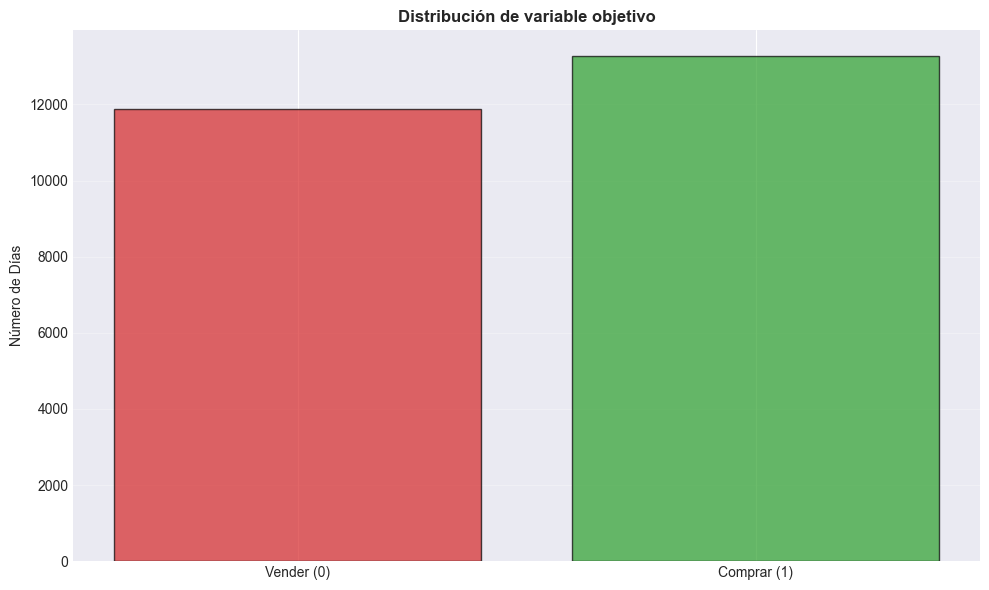

In [10]:
target_counts = df['Target'].value_counts().sort_index()
target_pct = (target_counts / len(df) * 100).round(1)

print(f"Y=0 (Vender):  {target_counts[0]:,} ({target_pct[0]}%)")
print(f"Y=1 (Comprar): {target_counts[1]:,} ({target_pct[1]}%)")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(['Vender (0)', 'Comprar (1)'], target_counts.values, 
              color=['#d62728', '#2ca02c'], alpha=0.7, edgecolor='black')

ax.set_ylabel('Número de Días')
ax.set_title('Distribución de variable objetivo', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Target por Ticker
target_ticker = df.groupby(['Ticker', 'Target']).size().unstack(fill_value=0)
target_ticker['% Comprar'] = (target_ticker[1] / target_ticker.sum(axis=1) * 100).round(1)
target_ticker = target_ticker.sort_values('% Comprar', ascending=False)
target_ticker

Target,0,1,% Comprar
Ticker,,,
NVDA,1143,1373,54.6000
GOOGL,1164,1352,53.7000
AMZN,1170,1346,53.5000
MSFT,1171,1345,53.5000
AAPL,1177,1339,53.2000
UNH,1186,1330,52.9000
META,1195,1321,52.5000
JPM,1213,1303,51.8000
TSLA,1213,1303,51.8000


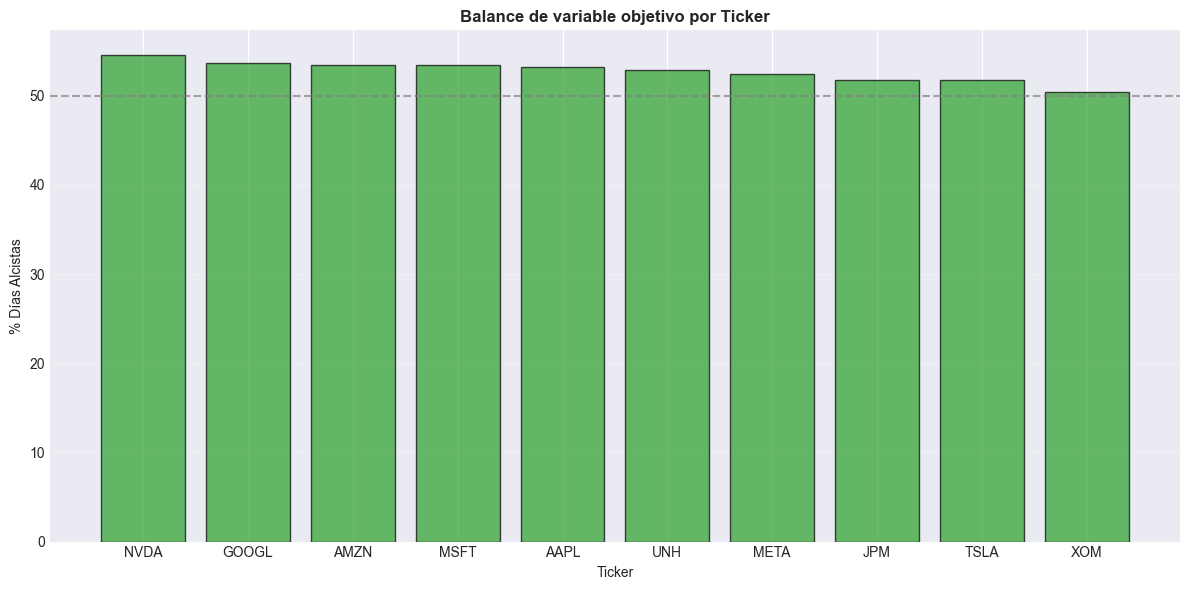

In [12]:
# Visualización Target por Ticker
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(target_ticker))
ax.bar(x, target_ticker['% Comprar'], color='#2ca02c', alpha=0.7, edgecolor='black')
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.7)
ax.set_ylabel('% Días Alcistas')
ax.set_xlabel('Ticker')
ax.set_title('Balance de variable objetivo por Ticker', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(target_ticker.index)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Target por Año
df['Year'] = pd.to_datetime(df['Date']).dt.year
target_year = df.groupby(['Year', 'Target']).size().unstack(fill_value=0)
target_year['% Comprar'] = (target_year[1] / target_year.sum(axis=1) * 100).round(1)
target_year

Target,0,1,% Comprar
Year,,,
2015,1250,1270,50.4000
2016,1186,1334,52.9000
2017,1143,1367,54.5000
2018,1217,1293,51.5000
2019,1146,1374,54.5000
2020,1180,1350,53.4000
2021,1175,1345,53.4000
2022,1283,1227,48.9000
2023,1144,1356,54.2000


### Hallazgos - Variable Objetivo

**Balance General Excelente**

Observamos un balance casi perfecto en la variable objetivo:

- **Y=0 (Vender):** 11,879 días (47.2%)
- **Y=1 (Comprar):** 13,281 días (52.8%)

Este balance es prácticamente ideal para un modelo de clasificación binaria. Un sesgo del 52.8% hacia días alcistas es consistente con la tendencia histórica alcista del S&P 500 en la última década, pero no es tan extremo como para generar problemas de desbalance de clases. Esto significa que:

- No será necesario aplicar técnicas de balanceo artificial (SMOTE, oversampling, undersampling).
- El modelo podrá aprender patrones tanto de días alcistas como bajistas sin sesgo significativo.
- Las métricas de evaluación (Accuracy, Precision, Recall) serán confiables sin necesidad de ajustes por desbalance.

**Diferencias Significativas por Ticker**

El análisis por ticker revela comportamientos diferenciados que reflejan las características de cada sector:

- **Tickers más alcistas:**
  - **NVDA (54.6%):** La acción más alcista del conjunto, reflejando el boom de semiconductores e inteligencia artificial en la última década.
  - **GOOGL (53.7%) y AMZN (53.5%):** Tecnológicas de alto crecimiento con tendencias alcistas sostenidas.
  - **MSFT (53.5%) y AAPL (53.2%):** Big Tech con crecimiento estable y dividendos, aunque ligeramente menos volátiles que las anteriores.

- **Tickers menos alcistas:**
  - **XOM (50.4%):** La acción menos alcista, prácticamente neutral. Esto refleja la volatilidad del sector energético, afectado por fluctuaciones en precios del petróleo y la transición energética.
  - **JPM y TSLA (51.8%):** JPM (financiero) muestra mayor estabilidad y menor tendencia alcista comparado con tecnológicas. TSLA, aunque es una acción de alto crecimiento, presenta alta volatilidad y correcciones frecuentes.

Es importante destacar que todos los tickers tienen un sesgo alcista, no es peligroso pero no está demás decirlo, lo cual es consistente con el periodo analizado (2015-2024), caracterizado por un bull market prolongado con pocas correcciones severas.

**Evolución Temporal del Mercado**

El análisis por año revela dinámicas macroeconómicas clave:

-**Años más alcistas:**
  - **2017 y 2019 (54.5%):** Años de fuerte crecimiento económico, tasas de interés bajas y optimismo corporativo.
  - **2023 y 2024 (54.2%):** Recuperación post-pandemia consolidada, boom de IA generativa, y rally de las "Magnificent Seven".

- **Años moderadamente alcistas:**
  - **2020 y 2021 (53.4%):** Aunque el promedio es alcista, estos años incluyen eventos extremos: el crash de marzo 2020 (COVID-19) seguido de una recuperación histórica impulsada por estímulos fiscales y monetarios.
  - **2016 (52.9%):** Año de transición política en EE.UU. con volatilidad electoral.

- **Año bajista:**
  - **2022 (48.9%):** El único año con sesgo bajista. Refleja el impacto de:
    - Políticas agresivas de la Fed para combatir inflación (subida de tasas de interés).
    - Guerra en Ucrania y disrupciones en cadenas de suministro.
    - Corrección del sector tecnológico tras años de sobrevaluación.

- **Años neutrales:**
  - **2015 (50.4%) y 2018 (51.5%):** Años con mercados laterales, caracterizados por incertidumbre sobre crecimiento global (desaceleración de China en 2015, guerra comercial en 2018).

**Implicaciones para el Modelo**

Este análisis temporal es crucial porque:

- El modelo verá ejemplos de diferentes regímenes de mercado (alcista, bajista, lateral).
- La presencia de 2022 como año bajista es valiosa para evitar overfitting a patrones exclusivamente alcistas.
- La diversidad temporal mejorará la capacidad de generalización del modelo a condiciones de mercado futuras.

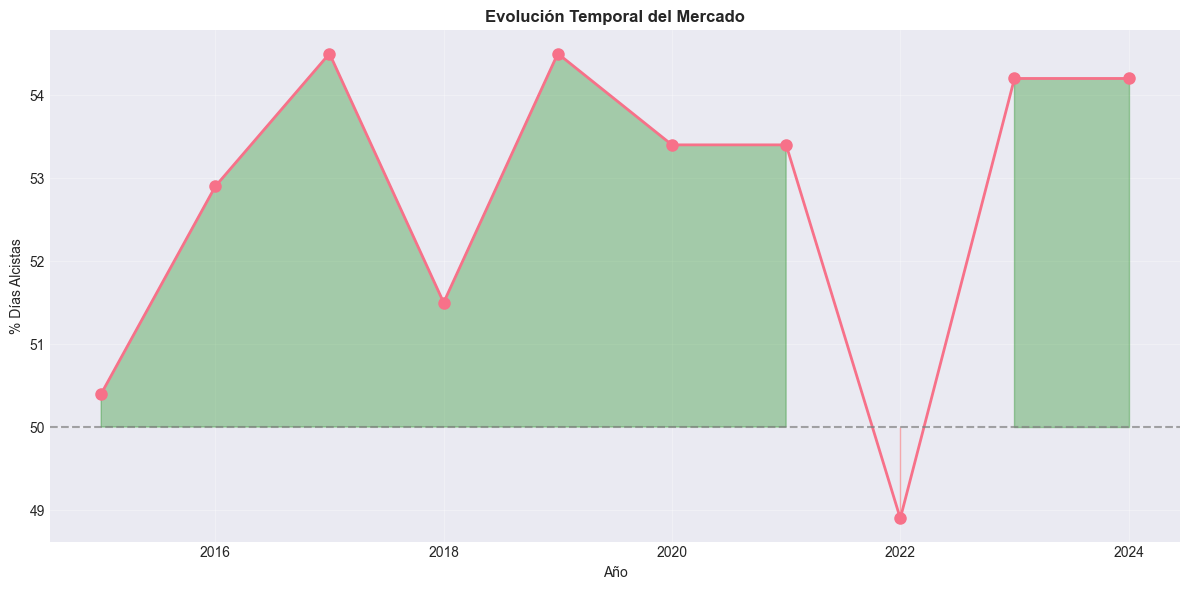

In [14]:
# Visualización Target por Año
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(target_year.index, target_year['% Comprar'], marker='o', linewidth=2, markersize=8)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.7)
ax.fill_between(target_year.index, 50, target_year['% Comprar'], 
                 where=(target_year['% Comprar'] >= 50), alpha=0.3, color='green')
ax.fill_between(target_year.index, 50, target_year['% Comprar'], 
                 where=(target_year['% Comprar'] < 50), alpha=0.3, color='red')
ax.set_ylabel('% Días Alcistas')
ax.set_xlabel('Año')
ax.set_title('Evolución Temporal del Mercado', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Distribuciones por Grupo

### Grupo 1: Tendencia

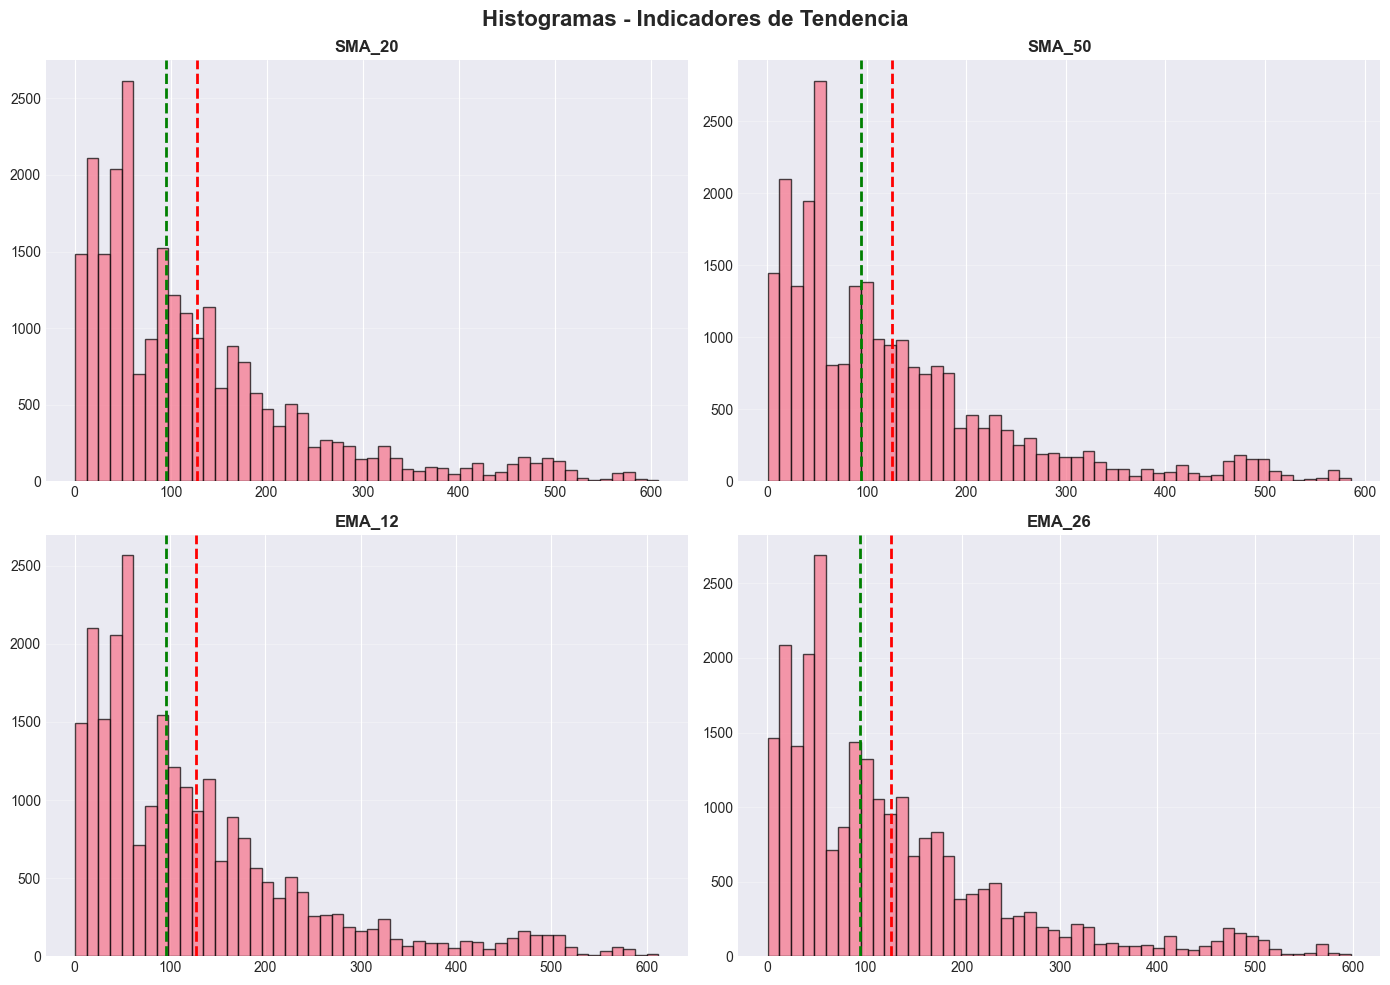

In [15]:
# Histogramas - Tendencia
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feature in enumerate(trend_features):
    axes[i].hist(df[feature].dropna(), bins=50, alpha=0.7, edgecolor='black')
    axes[i].axvline(df[feature].mean(), color='red', linestyle='--', linewidth=2)
    axes[i].axvline(df[feature].median(), color='green', linestyle='--', linewidth=2)
    axes[i].set_title(f'{feature}', fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Histogramas - Indicadores de Tendencia', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

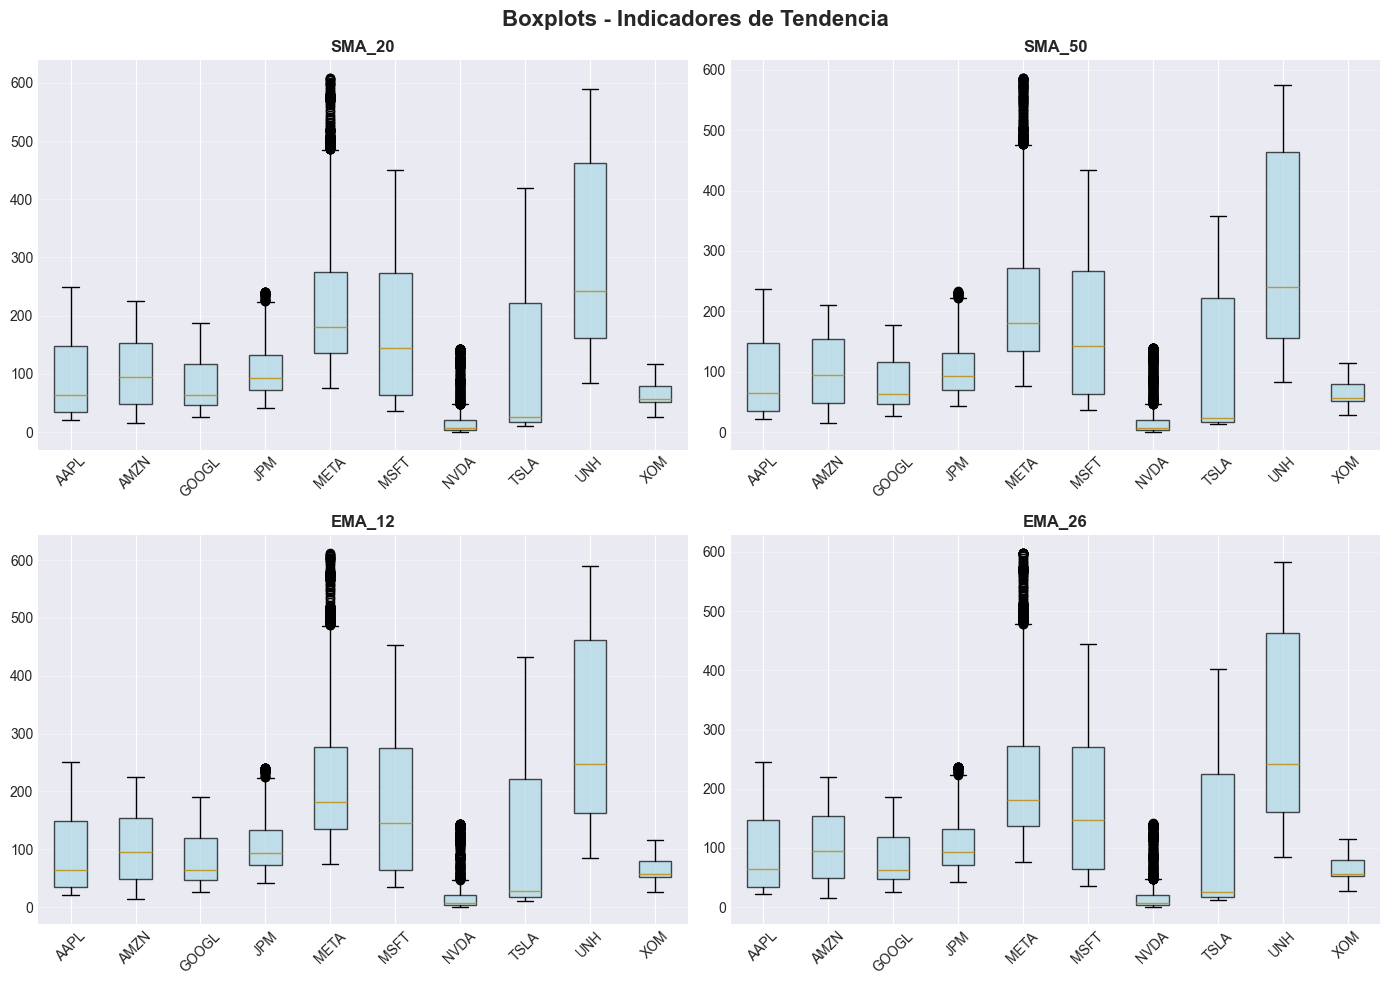

In [16]:
# Boxplots - Tendencia
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feature in enumerate(trend_features):
    bp = axes[i].boxplot([df[df['Ticker'] == t][feature].dropna() 
                           for t in sorted(df['Ticker'].unique())],
                          labels=sorted(df['Ticker'].unique()), patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    axes[i].set_title(f'{feature}', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Boxplots - Indicadores de Tendencia', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Los indicadores de tendencia (SMA_20, SMA_50, EMA_12, EMA_26) muestran patrones consistentes:

- **Distribuciones asimétricas positivas:** Los histogramas revelan concentraciones de valores en rangos bajos (~$40-100) con colas largas hacia la derecha, reflejando la diversidad de rangos de precios entre tickers. Tickers como NVDA, GOOGL y AMZN tienen precios sustancialmente más altos que el resto.

- **Diferencias entre tickers (boxplots):** Se observa claramente que:
  - **NVDA, GOOGL, AMZN:** Presentan medianas y rangos intercuartílicos significativamente más altos.
  - **Tickers de precios bajos:** Algunos tickers históricos muestran medias móviles concentradas en rangos inferiores.
  - **Outliers presentes:** Varios tickers muestran valores atípicos, especialmente en los extremos superiores, correspondientes a picos históricos de precios.

- **Consistencia entre indicadores:** Las cuatro medias móviles (SMA_20, SMA_50, EMA_12, EMA_26) exhiben formas de distribución prácticamente idénticas, lo cual es esperado ya que todas derivan del mismo precio subyacente. La principal diferencia radica en la velocidad de reacción: EMA reacciona más rápido a cambios de precio que SMA.

**Implicación:** Dada la alta correlación esperada entre estos cuatro indicadores de tendencia, es posible que exista multicolinealidad. Esto no afectará a modelos basados en árboles (Random Forest, XGBoost), pero so obtamos por modelos lineales podría ser necesario regularizar.

### Grupo 2: Momentum

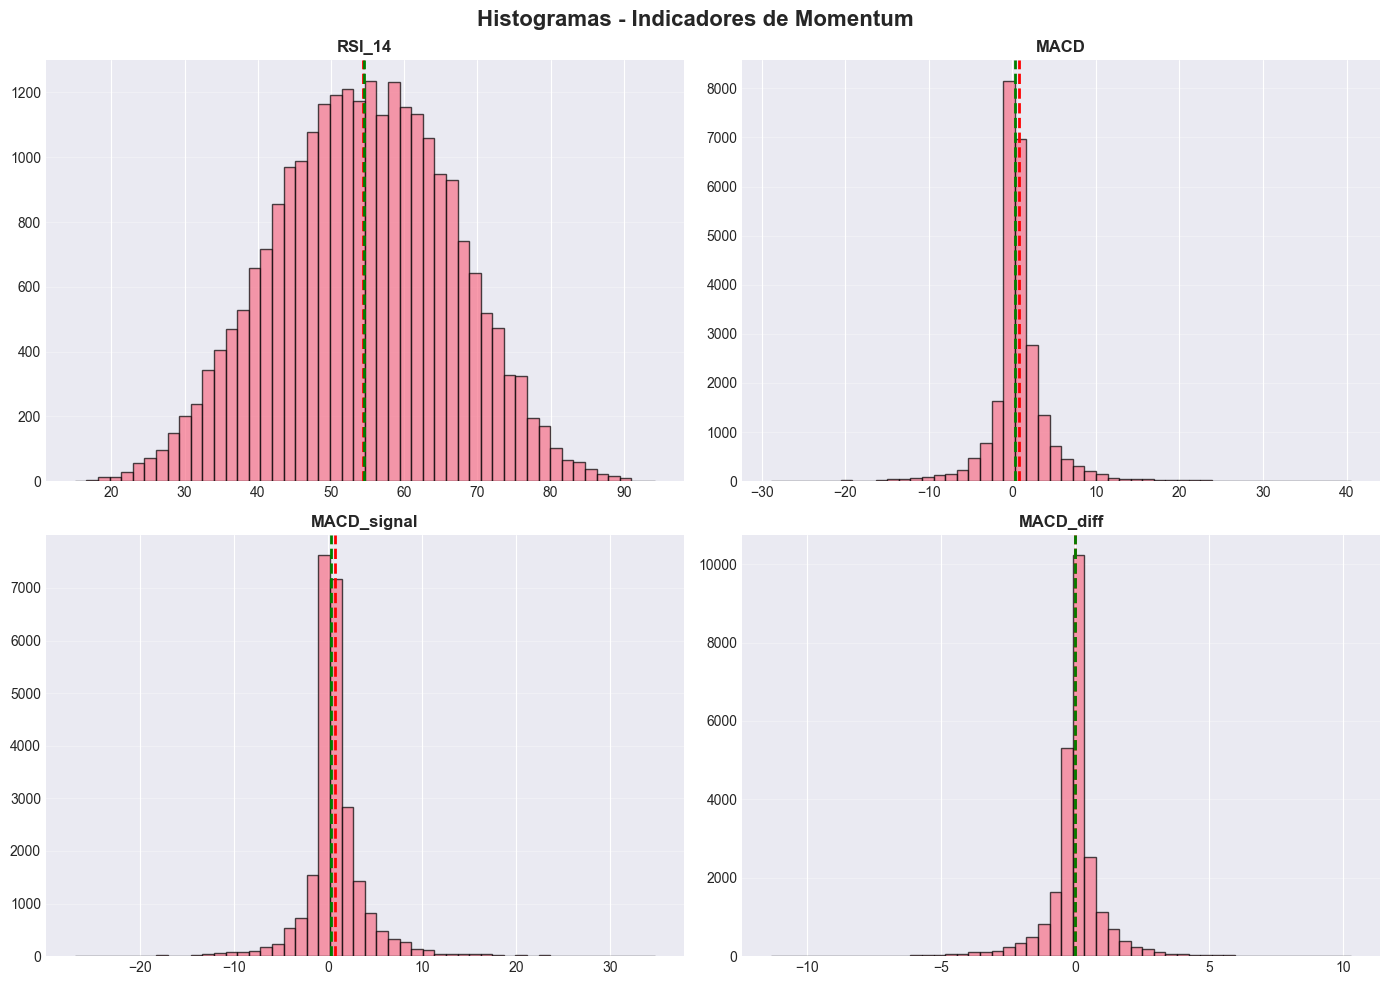

In [17]:
# Histogramas - Momentum
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feature in enumerate(momentum_features):
    axes[i].hist(df[feature].dropna(), bins=50, alpha=0.7, edgecolor='black')
    axes[i].axvline(df[feature].mean(), color='red', linestyle='--', linewidth=2)
    axes[i].axvline(df[feature].median(), color='green', linestyle='--', linewidth=2)
    axes[i].set_title(f'{feature}', fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Histogramas - Indicadores de Momentum', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

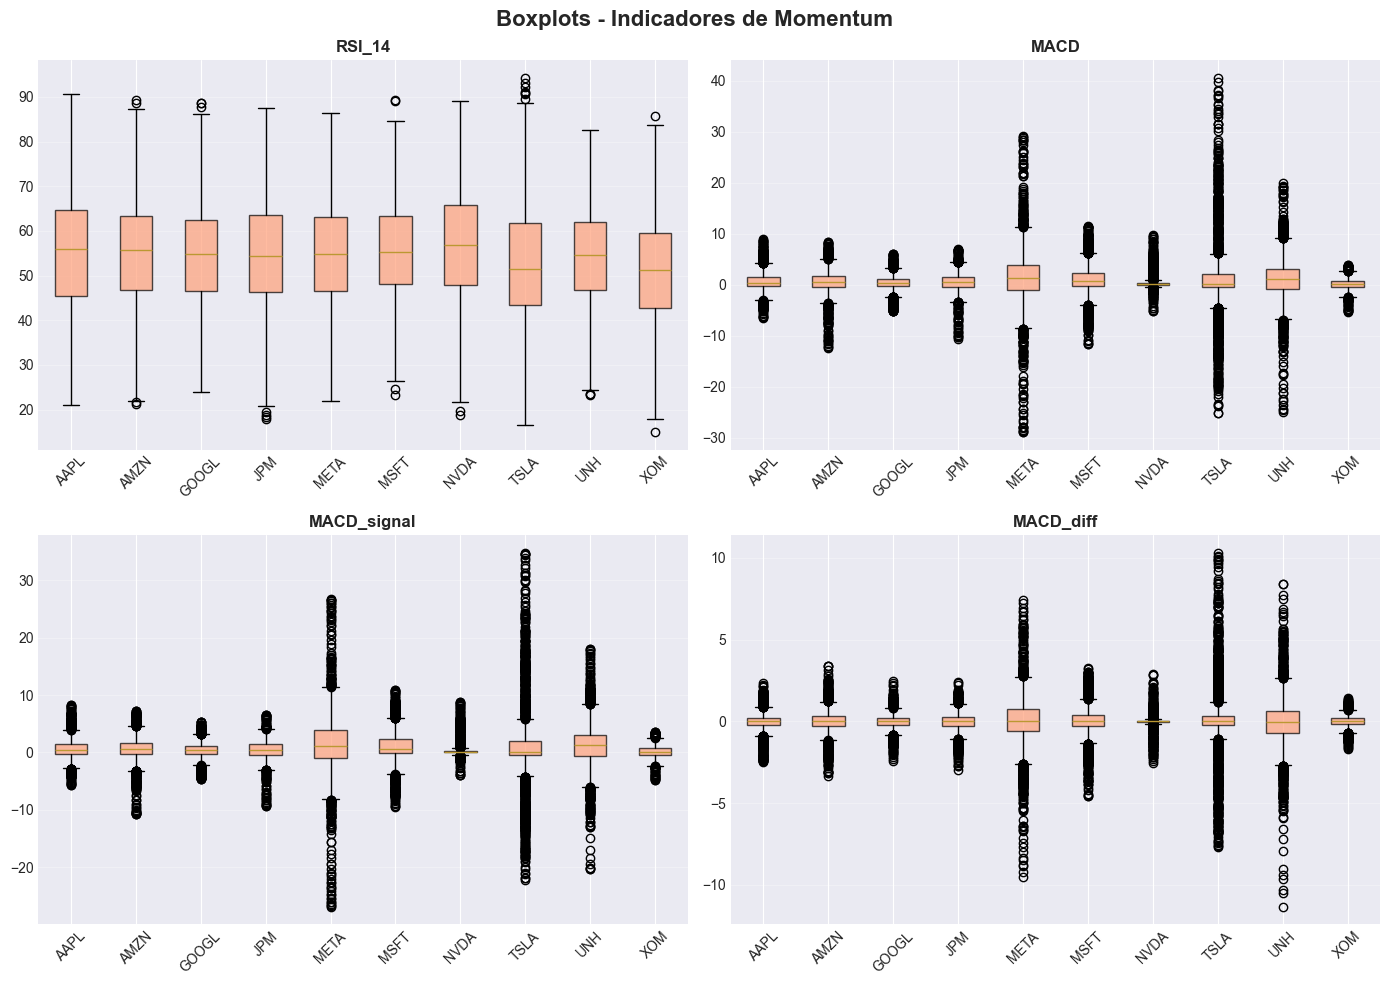

In [18]:
# Boxplots - Momentum
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feature in enumerate(momentum_features):
    bp = axes[i].boxplot([df[df['Ticker'] == t][feature].dropna() 
                           for t in sorted(df['Ticker'].unique())],
                          labels=sorted(df['Ticker'].unique()), patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightsalmon')
        patch.set_alpha(0.7)
    axes[i].set_title(f'{feature}', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Boxplots - Indicadores de Momentum', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Los indicadores de momentum revelan dinámicas de fuerza de mercado:

- **RSI_14 - Distribución simétrica:**
  - El histograma muestra una distribución casi normal centrada en ~54, con picos bien definidos en torno a los niveles 30 (sobreventa) y 70 (sobrecompra).
  - La simetría es valiosa porque indica que el mercado pasa tiempos comparables en condiciones normales, sobrecompra y sobreventa.
  - **Boxplots por ticker:** La mayoría de tickers tienen medianas de RSI entre 50-55, confirmando el sesgo alcista leve. NVDA presenta la mediana más alta, consistente con su carácter de growth stock.

- **MACD, MACD_signal, MACD_diff - Distribuciones con outliers:**
  - Los histogramas muestran concentraciones fuertes cerca de cero, con colas largas en ambas direcciones.
  - **MACD_diff (histograma MACD):** Centrado en cero, indicando que el mercado pasa proporciones similares de tiempo con momentum positivo y negativo. Los outliers extremos (-11 a +10) corresponden a reversiones bruscas de tendencia.
  - **Boxplots:** Se observan numerosos outliers en todos los tickers, reflejando eventos de alta volatilidad (earnings surprises, anuncios macro, crisis).

**Implicación:** Los outliers en MACD no necesariamente deben eliminarse, ya que representan señales genuinas de cambios drásticos de tendencia que el modelo debe aprender a identificar.

### Grupo 3: Volatilidad

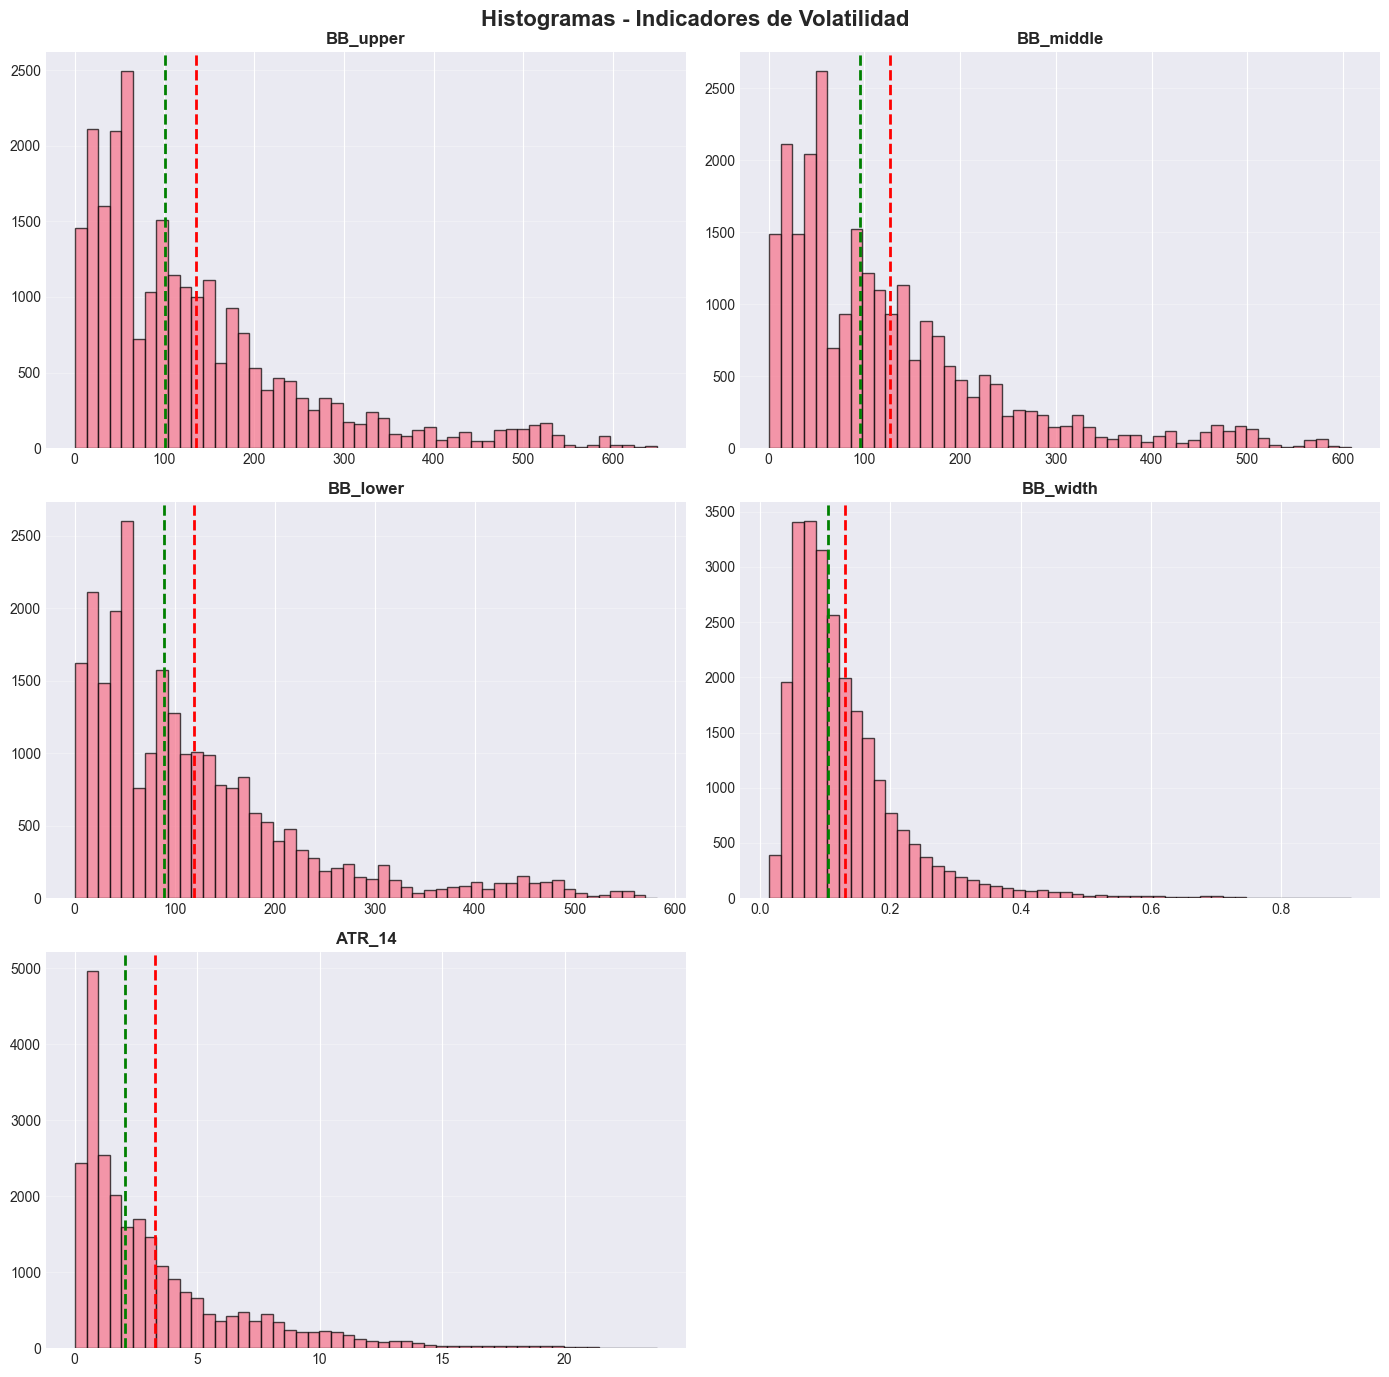

In [19]:
# Histogramas - Volatilidad
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.ravel()

for i, feature in enumerate(volatility_features):
    axes[i].hist(df[feature].dropna(), bins=50, alpha=0.7, edgecolor='black')
    axes[i].axvline(df[feature].mean(), color='red', linestyle='--', linewidth=2)
    axes[i].axvline(df[feature].median(), color='green', linestyle='--', linewidth=2)
    axes[i].set_title(f'{feature}', fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)

axes[5].axis('off')
plt.suptitle('Histogramas - Indicadores de Volatilidad', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

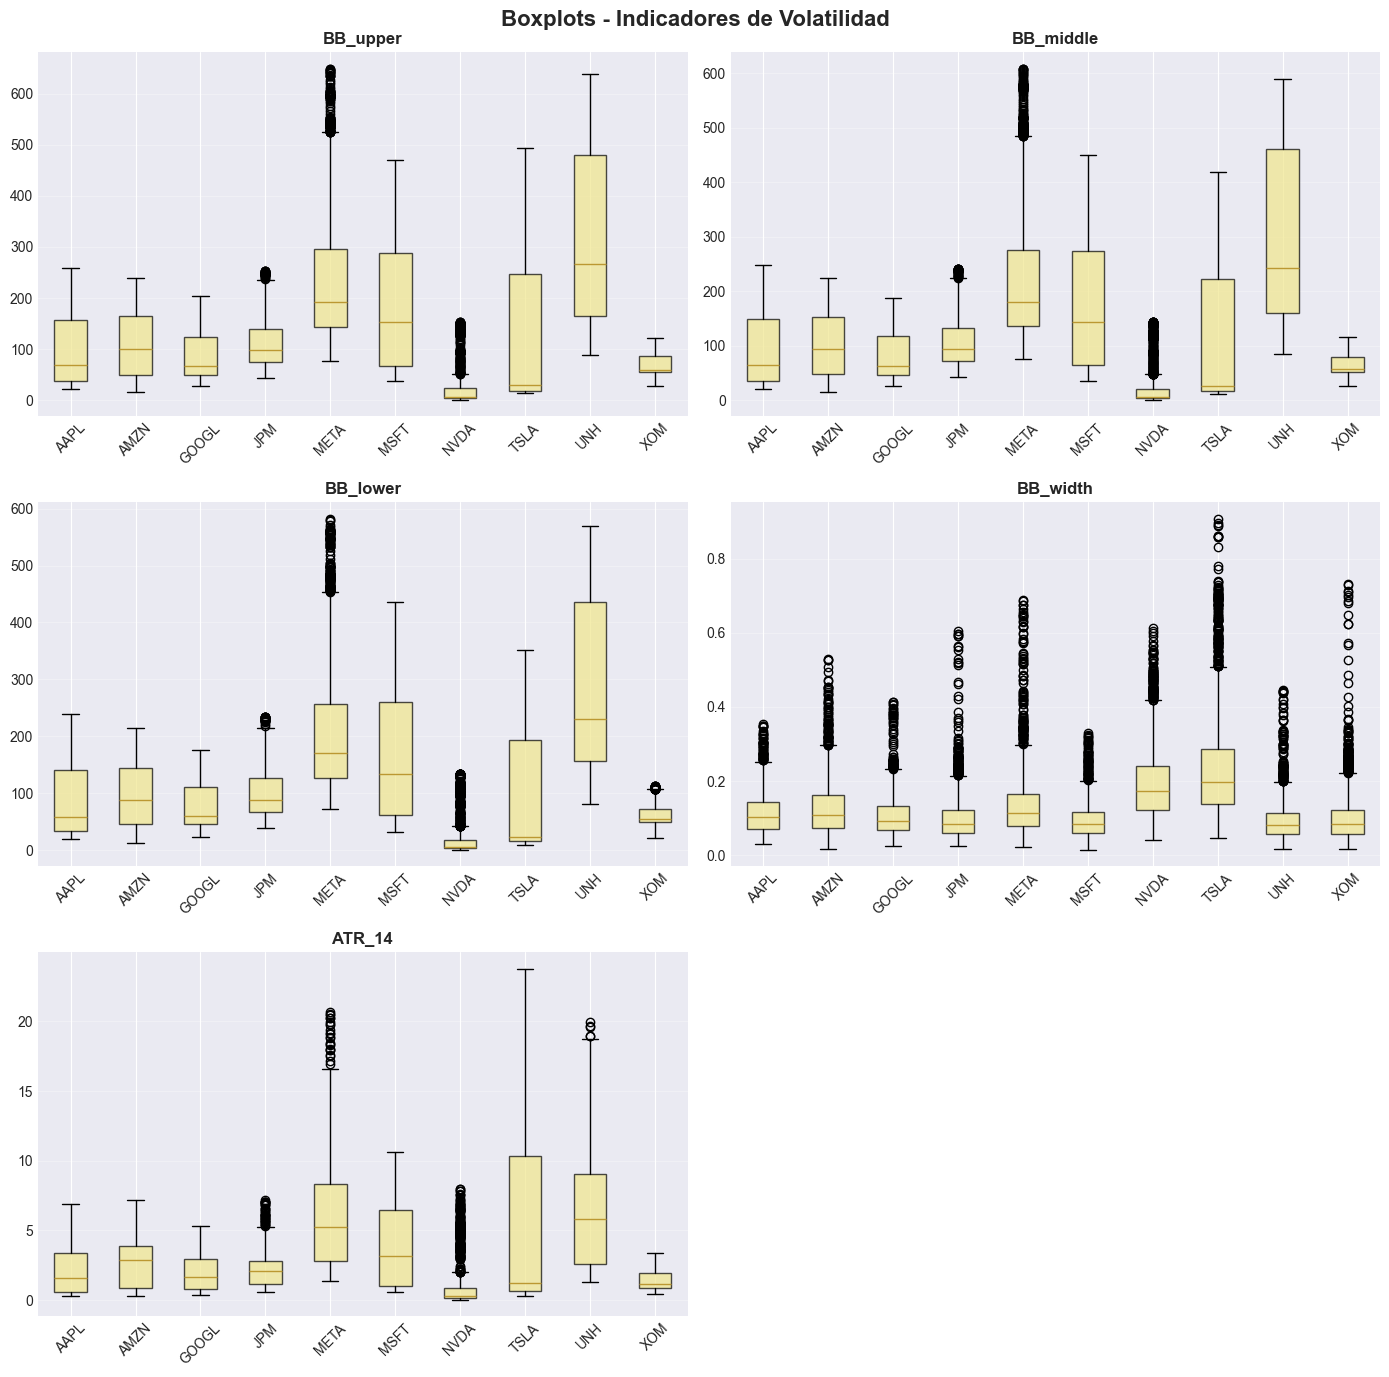

In [20]:
# Boxplots - Volatilidad
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.ravel()

for i, feature in enumerate(volatility_features):
    bp = axes[i].boxplot([df[df['Ticker'] == t][feature].dropna() 
                           for t in sorted(df['Ticker'].unique())],
                          labels=sorted(df['Ticker'].unique()), patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('khaki')
        patch.set_alpha(0.7)
    axes[i].set_title(f'{feature}', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.3)

axes[5].axis('off')
plt.suptitle('Boxplots - Indicadores de Volatilidad', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Los indicadores de volatilidad capturan la incertidumbre y riesgo del mercado:

- **Bollinger Bands (BB_upper, BB_middle, BB_lower):**
  - Las tres bandas muestran distribuciones prácticamente idénticas, simplemente desplazadas verticalmente. Esto es esperado ya que las bandas superior e inferior son BB_middle ± 2 desviaciones estándar.
  - **Diferenciación por ticker:** Los boxplots confirman que tickers de alto precio (NVDA, GOOGL) tienen bandas en rangos superiores.

- **BB_width - Indicador clave de volatilidad:**
  - El histograma muestra una distribución fuertemente sesgada hacia valores bajos (0.05-0.15), con una cola larga hacia la derecha.
  - **Valores extremos (>0.5):** Corresponden a periodos de crisis (marzo 2020, volatilidad de 2022), donde las bandas se expanden significativamente.
  - **Boxplots:** Todos los tickers tienen medianas similares de BB_width (~0.10), pero con outliers variables. TSLA y NVDA tienden a tener volatilidades más altas que JPM o XOM.

- **ATR_14 - Rango Verdadero Promedio:**
  - Similar a BB_width, el histograma está sesgado hacia valores bajos, con outliers en el extremo superior.
  - **Boxplots por ticker:** ATR_14 muestra correlación directa con el precio de la acción (tickers de alto precio tienen ATR más altos), lo cual es lógico: una acción de $500 puede oscilar $10 diarios, mientras una de $50 oscila $1-2.

**Implicación:** BB_width y ATR_14 son complementarios: BB_width mide volatilidad relativa (como % del precio), mientras ATR mide volatilidad absoluta (en dólares). Ambos aportan información valiosa para el modelo.

### Grupo 4: Volumen y Adicionales

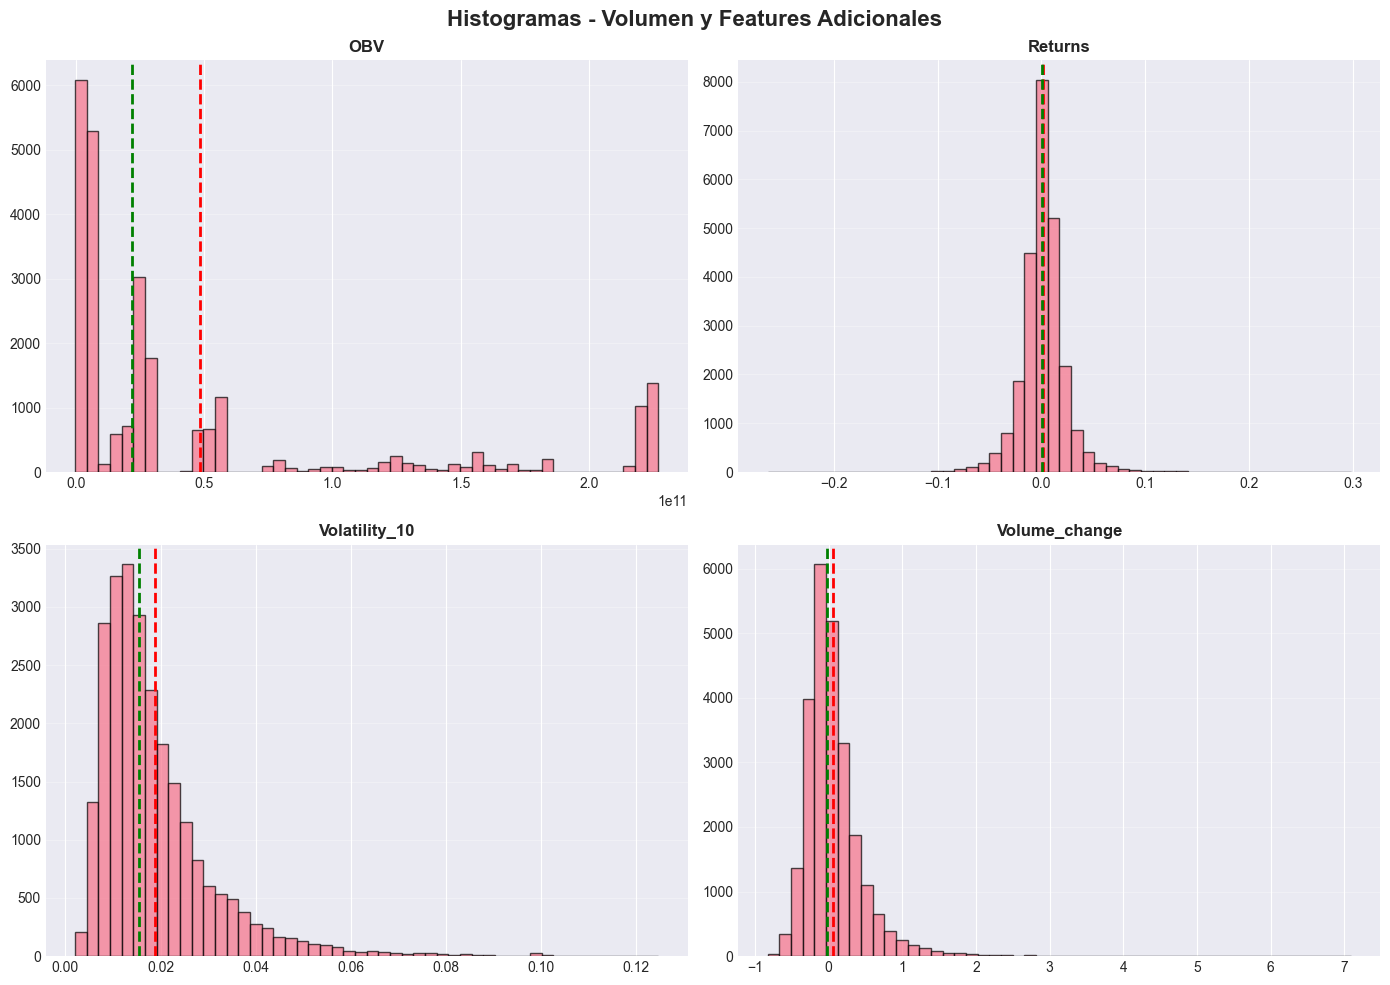

In [21]:
# Histogramas - Volumen
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feature in enumerate(volume_features):
    axes[i].hist(df[feature].dropna(), bins=50, alpha=0.7, edgecolor='black')
    axes[i].axvline(df[feature].mean(), color='red', linestyle='--', linewidth=2)
    axes[i].axvline(df[feature].median(), color='green', linestyle='--', linewidth=2)
    axes[i].set_title(f'{feature}', fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Histogramas - Volumen y Features Adicionales', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

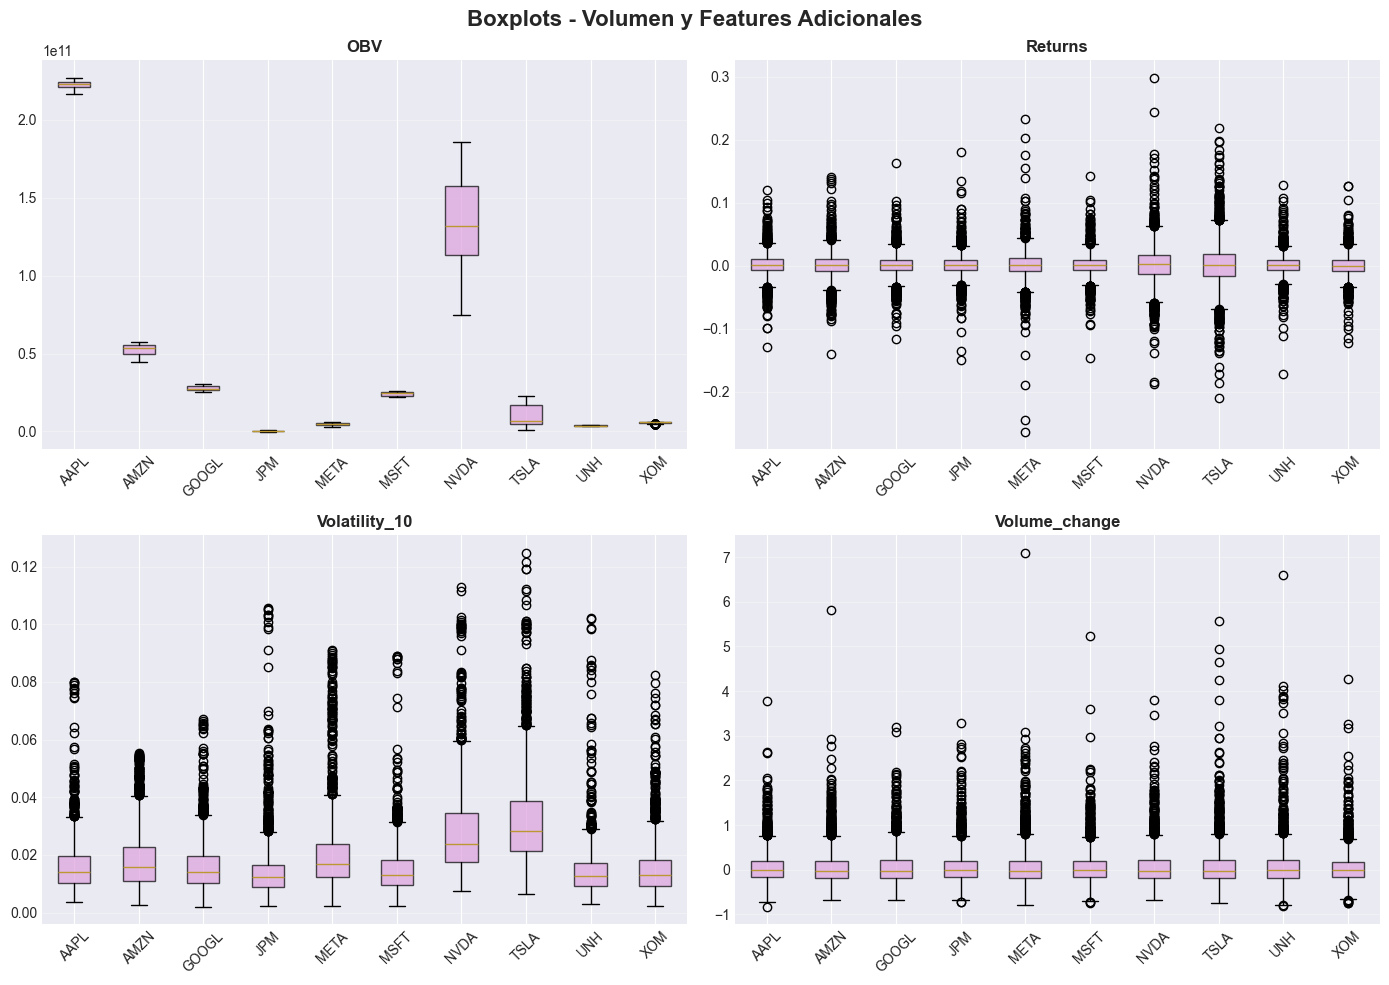

In [22]:
# Boxplots - Volumen
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feature in enumerate(volume_features):
    bp = axes[i].boxplot([df[df['Ticker'] == t][feature].dropna() 
                           for t in sorted(df['Ticker'].unique())],
                          labels=sorted(df['Ticker'].unique()), patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('plum')
        patch.set_alpha(0.7)
    axes[i].set_title(f'{feature}', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Boxplots - Volumen y Features Adicionales', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Este grupo captura aspectos de liquidez y comportamiento de retornos:

- **OBV (On-Balance Volume):**
  - El histograma muestra distribuciones multimodales, reflejando la enorme diferencia en capitalización entre tickers.
  - **Boxplots:** AAPL, MSFT, NVDA tienen OBV significativamente más altos (>50B) comparados con tickers de menor capitalización.
  - **Valores negativos:** Algunos tickers presentan OBV negativos, lo cual puede ocurrir si el volumen acumulado en días bajistas supera al de días alcistas desde el inicio del periodo de cálculo.

- **Returns - Retornos Diarios:**
  - El histograma muestra una distribución **casi normal** centrada en cero, con colas pesadas (kurtosis 12.07).
  - La mayoría de los días tienen retornos entre -2% y +2%, pero existen outliers extremos:
    - **Negativos:** Hasta -26% (crashes, e.g., marzo 2020).
    - **Positivos:** Hasta +30% (rallies post-crash, short squeezes).
  - **Boxplots:** Todos los tickers tienen medianas cercanas a cero, confirmando que la media de 0.12% se debe a un sesgo leve hacia retornos positivos, no a diferencias sistemáticas entre tickers.

- **Volatility_10 - Volatilidad de Ventana de 10 Días:**
  - El histograma está fuertemente sesgado hacia valores bajos (1-2%), con outliers hasta 12%.
  - **Periodos de alta volatilidad:** Los picos de Volatility_10 corresponden a eventos de mercado conocidos (COVID-19, correcciones de 2022).
  - **Boxplots:** TSLA y NVDA presentan medianas de volatilidad ligeramente superiores, reflejando su naturaleza de growth stocks con mayor riesgo.

- **Volume_change - Cambio Porcentual de Volumen:**
  - El histograma muestra una distribución extremadamente sesgada, con la mayoría de días entre -50% y +100%, pero con outliers hasta +700%.
  - **Interpretación:** Un cambio de +700% en volumen típicamente ocurre en días de earnings, anuncios corporativos clave, o eventos macroeconómicos.
  - **Boxplots:** Todos los tickers presentan numerosos outliers en ambas direcciones, confirmando que el volumen es una variable altamente volátil.

### Conclusión General de Distribuciones

- **Diversidad de comportamientos:** Cada grupo de indicadores captura dimensiones diferentes del mercado (tendencia, momentum, volatilidad, volumen), justificando la inclusión de todas las features.

- **Presencia de outliers significativos:** Los outliers no son errores de datos, sino eventos reales de mercado que el modelo debe aprender a interpretar.

- **Diferenciación por ticker:** Los boxplots confirman que cada ticker tiene características únicas, lo que enriquecerá el modelo al aprender patrones generalizables a través de múltiples acciones.

## 5. Correlaciones

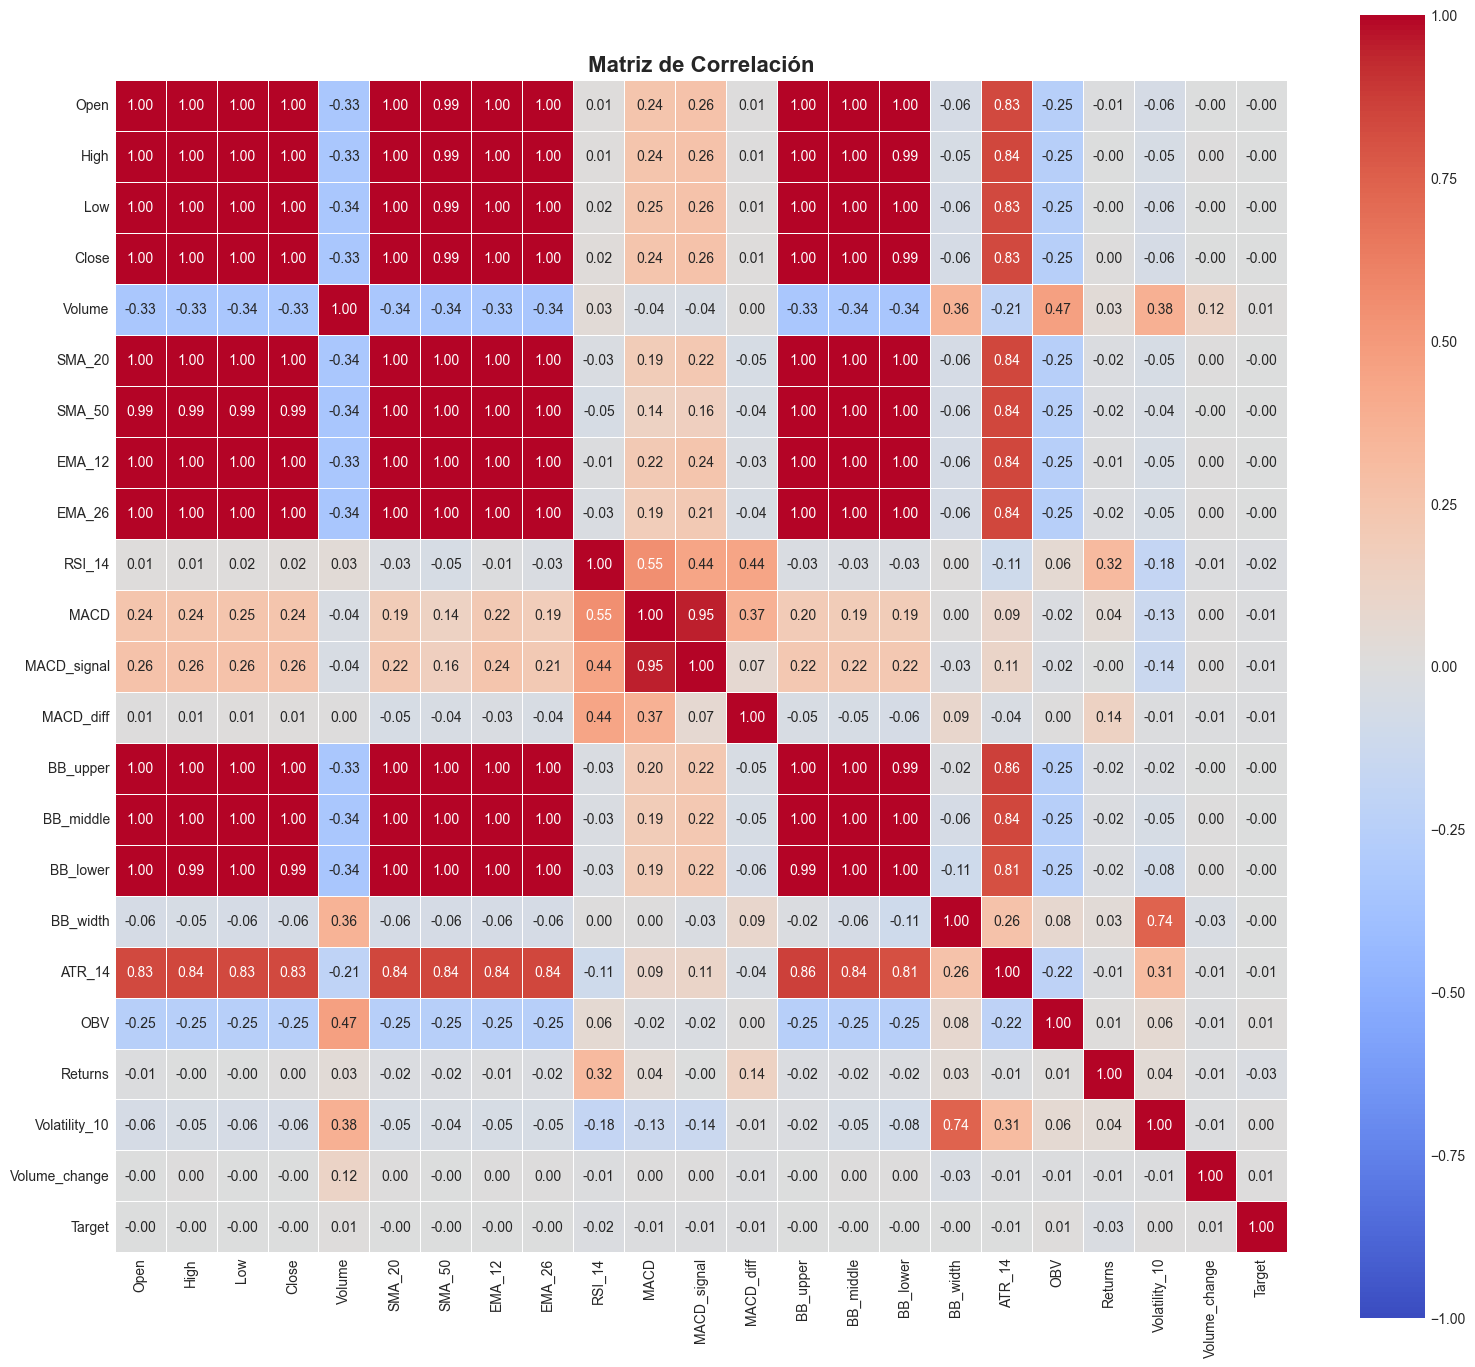

In [29]:
corr_matrix = df[feature_columns + ['Target']].corr()

corr_matrix.to_csv("../data/model_results/features_corr.csv")

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Matriz de Correlación', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
target_corr = corr_matrix['Target'].drop('Target').sort_values(key=abs, ascending=False)
print("Correlación con Target:")
print(target_corr)

Correlación con Target:
Returns         -0.0269
RSI_14          -0.0181
MACD_diff       -0.0146
MACD            -0.0131
Volume           0.0126
OBV              0.0102
MACD_signal     -0.0093
Volume_change    0.0059
ATR_14          -0.0051
Close           -0.0047
High            -0.0045
Low             -0.0044
Open            -0.0044
EMA_12          -0.0038
BB_upper        -0.0037
EMA_26          -0.0033
SMA_20          -0.0033
BB_middle       -0.0033
SMA_50          -0.0029
BB_lower        -0.0028
Volatility_10    0.0026
BB_width        -0.0001
Name: Target, dtype: float64


### Hallazgos - Correlaciones

**Correlaciones con Variable Objetivo (Target)**

El análisis de correlación con la variable objetivo revela un hallazgo crucial:

- **Correlaciones extremadamente bajas (<0.03):** Ningún indicador técnico individual muestra una correlación lineal fuerte con el Target. Las correlaciones más altas (en valor absoluto) son:
  - **Returns: -0.0269**
  - **RSI_14: -0.0181**
  - **MACD_diff: -0.0146**

**Interpretación:**

Esta ausencia de correlación lineal NO significa que los indicadores sean inútiles para predecir el Target. Por el contrario, esto indica que:

- **Relaciones no lineales:** Los indicadores técnicos probablemente tienen relaciones no lineales y complejas con el movimiento futuro del precio. Por ejemplo, RSI puede ser predictivo solo en valores extremos (>70 o <30), no linealmente en todo su rango.

- **Interacciones entre features:** La capacidad predictiva puede surgir de combinaciones de indicadores. Por ejemplo, un MACD positivo combinado con RSI <30 puede ser más predictivo que cada indicador por separado.

- **Modelos basados en árboles son ideales:** Random Forest y XGBoost capturan relaciones no lineales e interacciones, por lo que son apropiados para este dataset. Debido a la complejidad de las relaciones podría ser que los modelos lineales no sean tan buenos.

**Correlación negativa con Returns (-0.0269):**

Llama la atención que Returns (retorno del día actual) tenga la correlación más alta con Target, pero **negativa**. Esto puede reflejar un fenómeno de **reversión a la media**: días con grandes subidas (Returns alto) tienden a ser seguidos por correcciones (Target=0), y días con caídas (Returns bajo) tienden a rebotar (Target=1).

**Multicolinealidad entre Features**

El mapa de calor revela correlaciones altas entre ciertos grupos de indicadores:

**1. Indicadores de Tendencia - Multicolinealidad Extrema:**

- **SMA_20, SMA_50, EMA_12, EMA_26, BB_upper, BB_middle, BB_lower:**
  - Correlaciones entre **0.95 y 1.00** (casi perfectas).
  - **Explicación:** Todos estos indicadores derivan del precio de cierre, por lo que están fundamentalmente correlacionados.
  - **Impacto en modelado:**
    - **Modelos de árboles:** No hay problema. Los árboles pueden manejar multicolinealidad sin degradación de rendimiento.
    - **Modelos lineales:** Sería problemático. Podría requerir eliminación de features redundantes o regularización (Ridge, Lasso).

**2. MACD y MACD_signal - Alta Correlación (0.99):**

- El MACD_signal es una media móvil del MACD, por lo que están inherentemente correlacionados.
- **MACD_diff (histograma MACD) tiene correlación más baja (~0.5):** MACD_diff = MACD - MACD_signal, por lo que captura información diferente (velocidad de cambio del momentum).

**3. Indicadores de Volatilidad - Correlaciones Moderadas:**

- **BB_width y ATR_14:** Correlación de ~0.3-0.4 (moderada).
  - Ambos miden volatilidad, pero de formas diferentes:
    - BB_width: Volatilidad relativa (como % del precio).
    - ATR_14: Volatilidad absoluta (en dólares).
  - La correlación moderada sugiere que aportan información complementaria, no redundante.

**4. Indicadores de Volumen - Correlaciones Bajas:**

- **OBV, Volume_change:** Correlación baja (~0.1) entre sí.
- **OBV con indicadores de tendencia:** Correlación moderada (~0.3-0.5).
  - Esto es lógico: en tendencias alcistas, el volumen tiende a acumularse en días positivos (OBV sube).

**5. Returns y Volatility_10 - Independientes:**

- Correlación cercana a cero.
- **Interpretación:** El retorno diario (dirección) es independiente de la volatilidad (magnitud de oscilaciones), lo cual tiene sentido financieramente.

**Correlaciones Superiores a 0.80:**

Multicolinealidad Crítica, sin embargo, como a priori vamos a usar modelos basados en árboles no es necesario eliminar features correlacionadas.

Ahora bien, si en el algún momento decidimos explorar modelos lineales deberíamos obtar por:

- Mantener solo un representante de cada grupo correlacionado (e.g., SMA_20, eliminar SMA_50, EMA_12, EMA_26).
- Aplicar PCA para reducir dimensionalidad preservando varianza.
- Usar regularización Lasso para que el modelo seleccione automáticamente las features más relevantes.

**Conclusión General de Correlaciones**

- **Baja correlación con la variable objetivo:** Confirma que este es un problema complejo que requiere modelos capaces de capturar relaciones no lineales e interacciones.
- **Diversidad de información:** A pesar de algunas correlaciones altas, cada grupo de indicadores (tendencia, momentum, volatilidad, volumen) aporta perspectivas únicas sobre el comportamiento del mercado.

## 6. Análisis Temporal

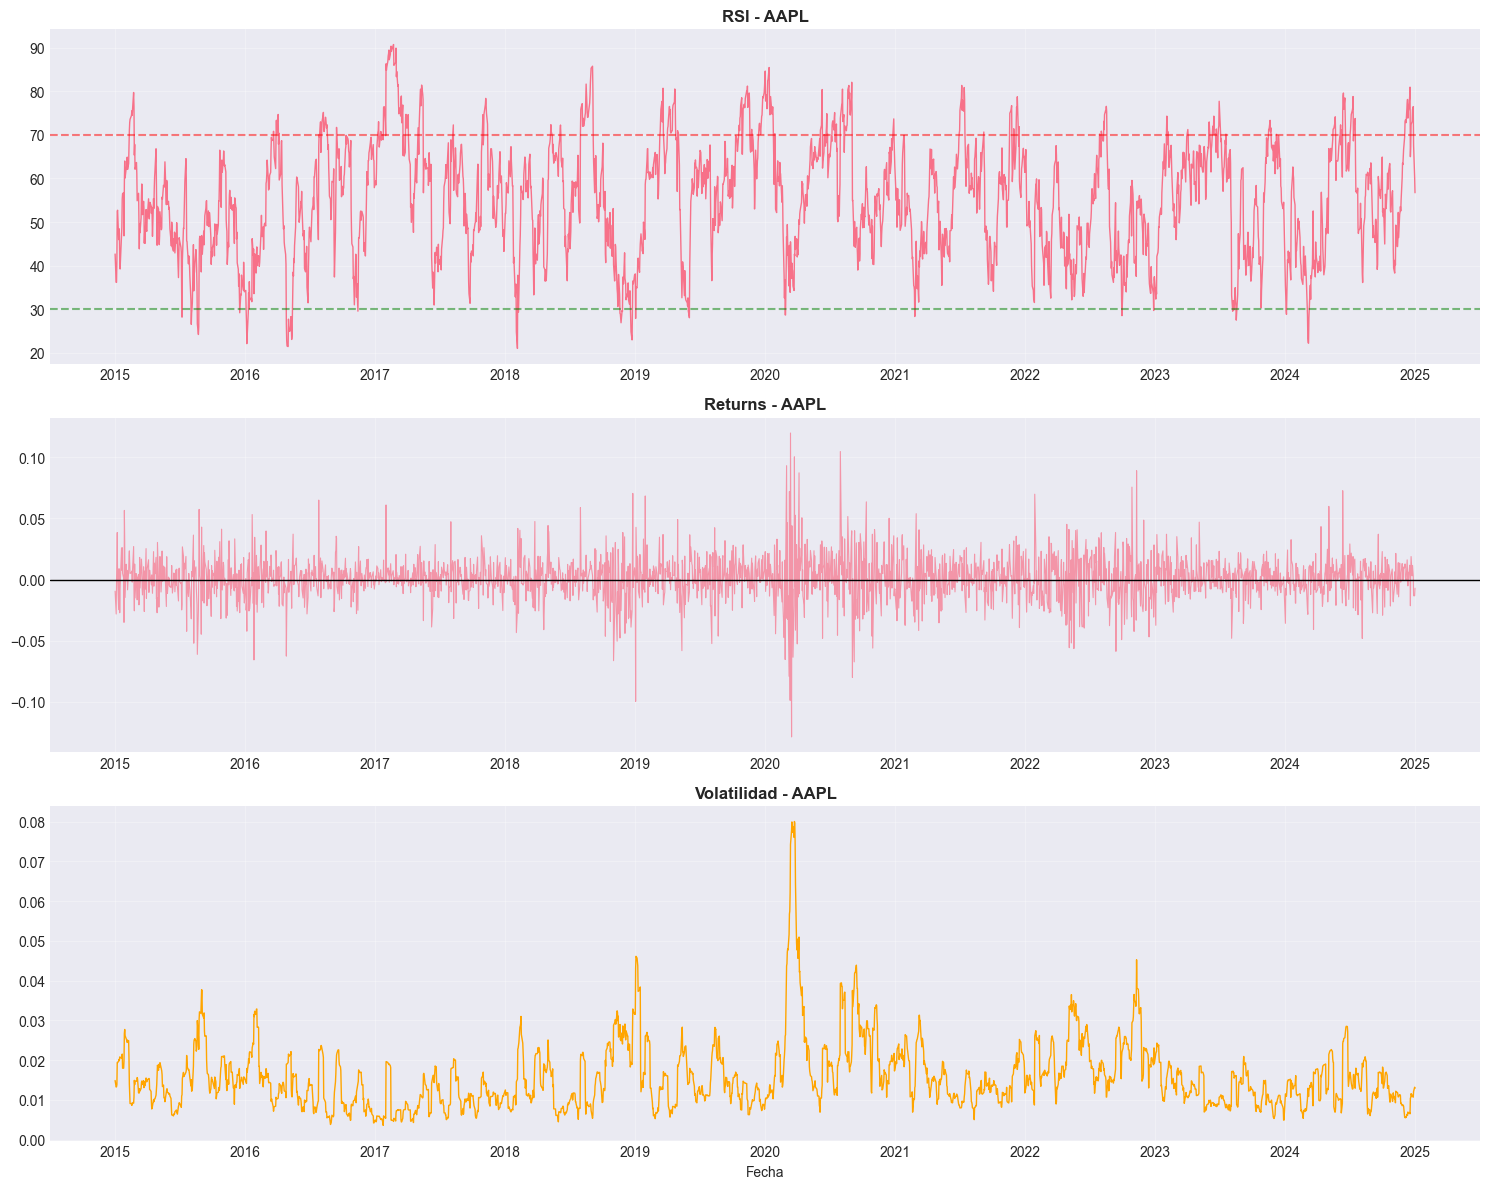

In [25]:
df_ticker = df[df['Ticker'] == 'AAPL'].sort_values('Date')

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

axes[0].plot(df_ticker['Date'], df_ticker['RSI_14'], linewidth=1)
axes[0].axhline(y=70, color='r', linestyle='--', alpha=0.5)
axes[0].axhline(y=30, color='g', linestyle='--', alpha=0.5)
axes[0].set_title(f'RSI - AAPL', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(df_ticker['Date'], df_ticker['Returns'], linewidth=0.8, alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_title(f'Returns - AAPL', fontweight='bold')
axes[1].grid(alpha=0.3)

axes[2].plot(df_ticker['Date'], df_ticker['Volatility_10'], linewidth=1, color='orange')
axes[2].set_title(f'Volatilidad - AAPL', fontweight='bold')
axes[2].set_xlabel('Fecha')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Hallazgos - Análisis Temporal (Ejemplo: AAPL)

El análisis temporal de AAPL (aunque sea una generalización peligrosa, puede que sea representativo del comportamiento general del mercado) revela patrones cíclicos y eventos clave:

**RSI_14 - Relative Strength Index**

Se observan claramente ciclos de sobrecompra y sobreventa a lo largo del periodo 2015-2024:

- **Zonas de Sobrecompra (RSI > 70):** Visibles en múltiples ocasiones, especialmente durante por periodos como el COVID y la aparición de la IA generativa.
- **Zonas de Sobreventa (RSI < 30):** Menos frecuentes, pero notables en periodos de correciones, el COVID y subidas de tasas de interés estadounidenses.
- **Oscilaciones rápidas:** El RSI muestra cambios bruscos en periodos cortos, reflejando la naturaleza volátil de las acciones tecnológicas. AAPL pasa de sobrecompra a neutral en cuestión de semanas durante correcciones.

**Returns - Retornos Diarios**

El gráfico de retornos diarios muestra:

- **Concentración cerca de cero:** La mayoría de los días, AAPL tiene retornos entre -2% y +2%, consistente con movimientos normales de mercado.
- **Picos extremos positivos:** En periodos de recuperación.
- **Picos extremos negativos:** La caída del COVID y en subidad de tasas de interés.
- **Clustering de volatilidad:** Se observa que los retornos extremos tienden a agruparse en periodos específicos (marzo 2020, 2022), un fenómeno conocido como **volatility clustering** en finanzas.

**Volatility_10 - Volatilidad de Ventana de 10 Días**

El gráfico de volatilidad revela claramente los regímenes de mercado:

- **Periodos de baja volatilidad (Volatility_10 < 2%):** Muestra un mercado estable, luego empieza el bull market con correcciones suaves y vuelve a estabilizarse después de las correcciones post-COVID.
- **Picos de alta volatilidad (Volatility_10 > 5%):** El COVID claramente generó mucha volatibilidad y luego otros factores como correcciones que pudieron haber afectado.
- **Persistencia de volatilidad:** Una vez que la volatilidad aumenta, tiende a mantenerse elevada durante semanas o meses antes de volver a niveles normales. Esto es consistente con la teoría de **volatility persistence** en finanzas.

**Patrones Temporales Generales**

Analizando los tres gráficos en conjunto:

- **Correlación entre Returns y Volatility_10:** Los picos en returns (positivos o negativos) coinciden temporalmente con aumentos en Volatility_10. Esto confirma que eventos extremos generan volatilidad sostenida.
- **Desfase entre RSI y Returns:** El RSI tiende a alcanzar niveles extremos (>70 o <30) después de movimientos sostenidos, mientras que Returns muestra spikes inmediatos. Esto sugiere que RSI es un indicador rezagado de acumulación de momentum.
- **Recuperación post-crisis:** En todos los casos de volatilidad extrema, AAPL eventualmente recuperó niveles de RSI normales (~50-60) y volatilidad baja, reflejando la resiliencia del mercado de acciones a largo plazo.
- **Eventos extremos:** Los eventos extremos generan patrones de inestabilidad que afectan a las tres gráficas, el más representativo fue el COVID.